In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('Sales2.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.groupby(['Date','Item Purchased'])['Sales'].sum()
data = pd.DataFrame(data, columns=['Sales'])

data=data.reset_index()
data = data.set_index('Date')

In [3]:
true_item=['Dress']
data = data.loc[data['Item Purchased'].isin(true_item)]

import copy
dataconcate=copy.copy(data)

scaler = MinMaxScaler()
data['Sales'] = scaler.fit_transform(data['Sales'].values.reshape(-1, 1))
data.head(5)

,Item Purchased,Sales
Date,,
2023-01-02,Dress,0.146341
2023-01-03,Dress,0.060976
2023-01-04,Dress,0.085366
2023-01-05,Dress,0.500000
2023-01-06,Dress,0.109756


In [4]:
train_size = int(len(data) * 0.7)
train_data, test_data = data[:train_size], data[train_size:]

def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length):
        sequence = data[i:i+sequence_length]
        target = data[i+sequence_length:i+sequence_length+1]
        sequences.append((sequence, target))
    return sequences

sequence_length = 10
train_sequences = create_sequences(train_data['Sales'], sequence_length)
test_sequences = create_sequences(test_data['Sales'], sequence_length)

X_train, y_train = np.array([seq[0] for seq in train_sequences]), np.array([seq[1] for seq in train_sequences])
X_test, y_test = np.array([seq[0] for seq in test_sequences]), np.array([seq[1] for seq in test_sequences])

# Build the LSTM model
!pip install tensorflow
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


In [5]:
model.fit(X_train, y_train, epochs=50, batch_size=32)
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

Epoch 1/50
2/2 [==============================] - 3s 18ms/step - loss: 0.0928
Epoch 2/50
2/2 [==============================] - 0s 11ms/step - loss: 0.0842
Epoch 3/50
2/2 [==============================] - 0s 12ms/step - loss: 0.0786
Epoch 4/50
2/2 [==============================] - 0s 13ms/step - loss: 0.0738
Epoch 5/50
2/2 [==============================] - 0s 11ms/step - loss: 0.0695
Epoch 6/50
2/2 [==============================] - 0s 12ms/step - loss: 0.0662
Epoch 7/50
2/2 [==============================] - 0s 12ms/step - loss: 0.0635
Epoch 8/50
2/2 [==============================] - 0s 11ms/step - loss: 0.0616
Epoch 9/50
2/2 [==============================] - 0s 11ms/step - loss: 0.0603
Epoch 10/50
2/2 [==============================] - 0s 11ms/step - loss: 0.0601
Epoch 11/50
2/2 [==============================] - 0s 12ms/step - loss: 0.0620
Epoch 12/50
2/2 [==============================] - 0s 12ms/step - loss: 0.0637
Epoch 13/50
2/2 [==============================] - 0s 12ms/st

In [6]:
# Inverse transform the scaled predictions to get actual sales values
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)

In [7]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print(test_predictions)

Train RMSE: 15.58252789746038
Test RMSE: 10.97195923896381
[[10.332106 ]
 [10.144961 ]
 [ 9.9899845]
 [ 9.7664   ]
 [ 9.682951 ]
 [10.863073 ]
 [11.248247 ]
 [13.110329 ]
 [12.616932 ]
 [12.011549 ]]


In [8]:
import tensorflow as tf
# Predict sales for future time steps
time_steps = sequence_length
future_time_steps = 60
future_data = data['Sales'].values[-time_steps:].reshape(1, -1, 1)
future_data = future_data.reshape(1, time_steps, 1)
future_predictions = []

for _ in range(future_time_steps):
    next_prediction = model.predict(tf.convert_to_tensor(future_data))
    future_predictions.append(next_prediction[0, 0])
    future_data = np.append(future_data[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Inverse transform the future predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future timestamps
last_timestamp = data.index[-1]
future_timestamps = pd.date_range(start=last_timestamp, periods=future_time_steps+1, freq=data.index.freq)



1/1 [==============================] - 0s 60ms/step


In [9]:
print(future_predictions)

[[11.42182  ]
 [11.771576 ]
 [12.110018 ]
 [12.429724 ]
 [12.706138 ]
 [12.873585 ]
 [13.0567875]
 [13.164366 ]
 [13.375198 ]
 [13.569619 ]
 [13.740931 ]
 [13.819519 ]
 [13.885518 ]
 [13.940506 ]
 [13.985998 ]
 [14.023569 ]
 [14.054811 ]
 [14.080564 ]
 [14.101855 ]
 [14.118793 ]
 [14.132117 ]
 [14.1425905]
 [14.15111  ]
 [14.158029 ]
 [14.163637 ]
 [14.168173 ]
 [14.171839 ]
 [14.174792 ]
 [14.177175 ]
 [14.179086 ]
 [14.180631 ]
 [14.181871 ]
 [14.182878 ]
 [14.183686 ]
 [14.184339 ]
 [14.184866 ]
 [14.185293 ]
 [14.185636 ]
 [14.18591  ]
 [14.186133 ]
 [14.186313 ]
 [14.186459 ]
 [14.186576 ]
 [14.18667  ]
 [14.186745 ]
 [14.186809 ]
 [14.186858 ]
 [14.186897 ]
 [14.18693  ]
 [14.1869545]
 [14.186975 ]
 [14.186991 ]
 [14.187005 ]
 [14.1870165]
 [14.187026 ]
 [14.187033 ]
 [14.1870365]
 [14.187043 ]
 [14.187045 ]
 [14.18705  ]]


In [10]:
future_timestamps=future_timestamps[1:]
future_timestamps

DatetimeIndex(['2023-04-27', '2023-04-28', '2023-04-29', '2023-04-30',
               '2023-05-01', '2023-05-02', '2023-05-03', '2023-05-04',
               '2023-05-05', '2023-05-06', '2023-05-07', '2023-05-08',
               '2023-05-09', '2023-05-10', '2023-05-11', '2023-05-12',
               '2023-05-13', '2023-05-14', '2023-05-15', '2023-05-16',
               '2023-05-17', '2023-05-18', '2023-05-19', '2023-05-20',
               '2023-05-21', '2023-05-22', '2023-05-23', '2023-05-24',
               '2023-05-25', '2023-05-26', '2023-05-27', '2023-05-28',
               '2023-05-29', '2023-05-30', '2023-05-31', '2023-06-01',
               '2023-06-02', '2023-06-03', '2023-06-04', '2023-06-05',
               '2023-06-06', '2023-06-07', '2023-06-08', '2023-06-09',
               '2023-06-10', '2023-06-11', '2023-06-12', '2023-06-13',
               '2023-06-14', '2023-06-15', '2023-06-16', '2023-06-17',
               '2023-06-18', '2023-06-19', '2023-06-20', '2023-06-21',
      

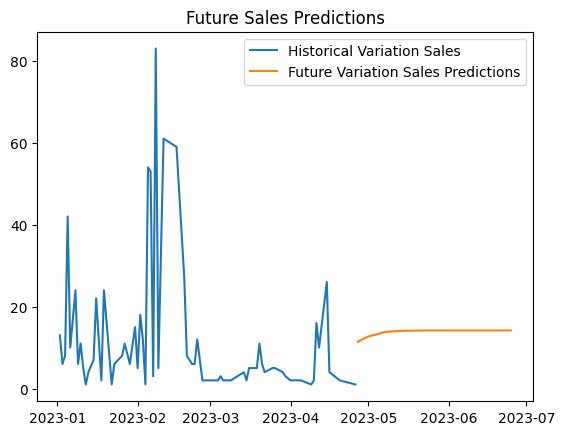

In [11]:
sale2nextmonth=pd.DataFrame(future_predictions,columns=['sale_prediction'], index=future_timestamps)

csv_file_path = 'predictsale2nextmonth_dress.csv'
# Export the DataFrame to a CSV file
sale2nextmonth.to_csv(csv_file_path)

# Plot the results
plt.plot(data.index, scaler.inverse_transform(data['Sales'].values.reshape(-1, 1)), label='Historical Variation Sales')
plt.plot(future_timestamps, future_predictions, label='Future Variation Sales Predictions')
plt.legend()
plt.title('Future Sales Predictions')
plt.show()

In [12]:
print(sale2nextmonth)

            sale_prediction
2023-04-27        11.421820
2023-04-28        11.771576
2023-04-29        12.110018
2023-04-30        12.429724
2023-05-01        12.706138
2023-05-02        12.873585
2023-05-03        13.056787
2023-05-04        13.164366
2023-05-05        13.375198
2023-05-06        13.569619
2023-05-07        13.740931
2023-05-08        13.819519
2023-05-09        13.885518
2023-05-10        13.940506
2023-05-11        13.985998
2023-05-12        14.023569
2023-05-13        14.054811
2023-05-14        14.080564
2023-05-15        14.101855
2023-05-16        14.118793
2023-05-17        14.132117
2023-05-18        14.142591
2023-05-19        14.151110
2023-05-20        14.158029
2023-05-21        14.163637
2023-05-22        14.168173
2023-05-23        14.171839
2023-05-24        14.174792
2023-05-25        14.177175
2023-05-26        14.179086
2023-05-27        14.180631
2023-05-28        14.181871
2023-05-29        14.182878
2023-05-30        14.183686
2023-05-31        14

In [13]:
sale8month = pd.concat([dataconcate, sale2nextmonth],axis=1)
sale8month

,Item Purchased,Sales,sale_prediction
2023-01-02,Dress,13.0,NaN
2023-01-03,Dress,6.0,NaN
2023-01-04,Dress,8.0,NaN
2023-01-05,Dress,42.0,NaN
2023-01-06,Dress,10.0,NaN
...,...,...,...
2023-06-21,NaN,NaN,14.187033
2023-06-22,NaN,NaN,14.187037
2023-06-23,NaN,NaN,14.187043
2023-06-24,NaN,NaN,14.187045


In [14]:
csv_file_path = 'sale6nextmonth_dress.csv'
sale8month.to_csv(csv_file_path)

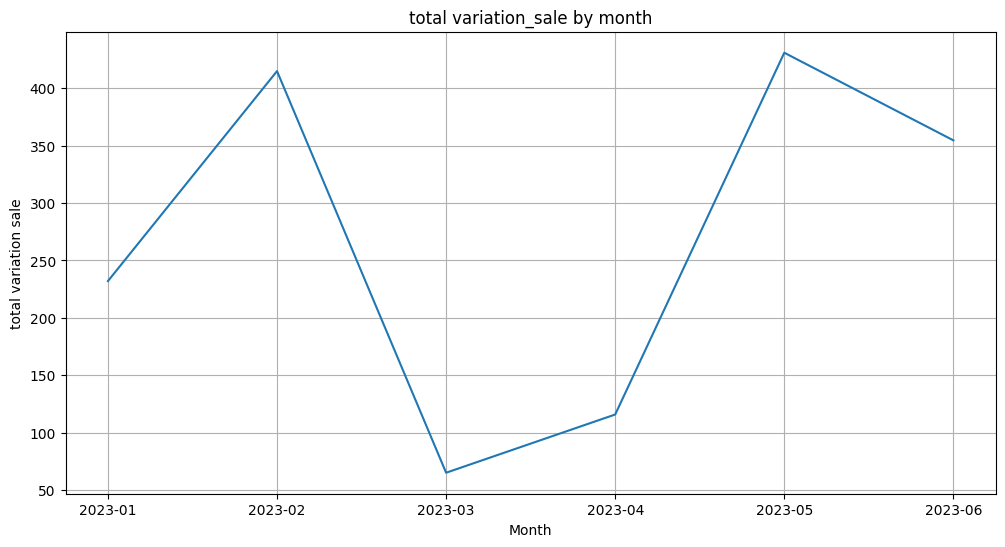

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sale6nextmonth_dress.csv")
df = df.rename(columns={'Unnamed: 0': 'date'})

for index, row in df.iterrows():
    if pd.isna(df.at[index, "Sales"]):
        df.at[index, "Sales"] = row["sale_prediction"]

monthly_sales = df.groupby(pd.to_datetime(df['date']).dt.strftime('%Y-%m'))['Sales'].sum().reset_index()

# Đổi tên cột
monthly_sales = monthly_sales.rename(columns={'index': 'month', 'Sales': 'total_variation_sale'})

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["date"], monthly_sales['total_variation_sale'])
plt.title('total variation_sale by month')
plt.xlabel('Month')
plt.ylabel('total variation sale')
plt.grid()
plt.show()